In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#importing the filtered powerlifting data
#source: OpenPowerlifting (openpowerlifting.org) - pre-filtered to Raw SBD meets 2015+, lifters with 2+ meets
df = pd.read_csv('data/raw/openpowerlifting_filtered.csv')

print(df.shape)
df.head()

#dataset seems to have enough observations to train a proper data set with over 700k after a pre filter round with lifters that have at least 2 meets allowing for
#comparison across time

(714698, 10)


,Name,Sex,Age,BodyweightKg,Best3SquatKg,Best3BenchKg,Best3DeadliftKg,TotalKg,Country,Date
0,A I Temaki,M,35.5,154.70,370.0,212.0,235.0,817.0,Nauru,2024-04-13
1,A I Temaki,M,36.0,145.45,400.0,220.0,235.0,855.0,Nauru,2025-03-29
2,A Madhuri,F,14.5,74.50,112.5,50.0,127.5,290.0,NaN,2022-04-09
3,A Madhuri,F,15.5,75.27,117.5,55.0,115.0,287.5,NaN,2023-06-08
4,A Madhuri,F,16.5,76.00,115.0,60.0,125.0,300.0,NaN,2024-06-06


In [4]:
#check what columns we have and their types
print(df.dtypes)
print(df.isna().sum())

Name                object
Sex                 object
Age                float64
BodyweightKg       float64
Best3SquatKg       float64
Best3BenchKg       float64
Best3DeadliftKg    float64
TotalKg            float64
Country             object
Date                object
dtype: object
Name                    0
Sex                     0
Age                     0
BodyweightKg            0
Best3SquatKg          102
Best3BenchKg          125
Best3DeadliftKg       109
TotalKg                 0
Country            133579
Date                    0
dtype: int64


In [ ]:
#convert Date to datetime so we can sort meets in order per lifter
df['Date'] = pd.to_datetime(df['Date'])

#sort by lifter name then date - this is important because we need meets in chronological order for each lifter
#to calculate whether the lifter improved from their last meet
df = df.sort_values(['Name', 'Date']).reset_index(drop=True)

In [ ]:
# For each lifter, we want to know what they lifted at their previous meet as a comparison basis
# This is the same idea as looking at a user's previous workout in Milo
# groupby Name then shift(1) gives us the row from one meet ago

df['prev_total']     = df.groupby('Name')['TotalKg'].shift(1)
df['prev_squat']     = df.groupby('Name')['Best3SquatKg'].shift(1)
df['prev_bench']     = df.groupby('Name')['Best3BenchKg'].shift(1)
df['prev_deadlift']  = df.groupby('Name')['Best3DeadliftKg'].shift(1)
df['prev_bodyweight']= df.groupby('Name')['BodyweightKg'].shift(1)
df['prev_date']      = df.groupby('Name')['Date'].shift(1)

#rows where prev values are NaN are the first meet get dropped because we cant use them in a comparison
df = df.dropna(subset=['prev_total', 'prev_squat', 'prev_bench', 'prev_deadlift']).reset_index(drop=True)

print(df.shape)

(374869, 16)


In [12]:
# The target variable for our classifation analsys will be Improved which takes on boolean values and predicts if our user will improve their weight or not on an excersize
# improved = True if the lifter increased their total kg compared to their previous meet
# improved = False if they stayed the same or went down
# This is what we are trying to predict: did the athlete improve?

df['improved'] = df['TotalKg'] > df['prev_total']

print(df['improved'].value_counts())
print(round(df['improved'].value_counts(normalize=True), 3))

# This distribution is not necessarily optimal to do a classfication which in a perfect world would be 50/50 but its not so imbalanced that it would require resampling
# the data the way to fix this without resampling is by tuning the classifaction threshold to maximize the F1 score which will have to be done in the model tuning stage
# WHOVEVER IS DOING THE MODEL TUNING REMEMBER THIS

improved
True     230848
False    144021
Name: count, dtype: int64
improved
True     0.616
False    0.384
Name: proportion, dtype: float64


In [14]:
# Finding days between meets to split into time intrevals
# How long did the lifter rest between competitions?
# Shorter breaks may mean less recovery - similar to tracking rest days in Milo

df['days_between_meets'] = (df['Date'] - df['prev_date']).dt.days

# check the distribution before binning
print(df['days_between_meets'].describe())
print(df['days_between_meets'].value_counts().sort_index().head(20))

count    374869.000000
mean        230.288736
std         285.220371
min           0.000000
25%          77.000000
50%         160.000000
75%         278.000000
max        3885.000000
Name: days_between_meets, dtype: float64
days_between_meets
0     40817
1       337
2        41
3        63
4        45
5        98
6       168
7       620
8       231
9       124
10      111
11      224
12      175
13      311
14      795
15      313
16      162
17      254
18      191
19      229
Name: count, dtype: int64


In [15]:
# Grouping the days between meets into catagories
# Classification models need boolean values this is why we do it 
# We group the numeric days_between_meets into labelled bands.
# After get_dummies() later, each band becomes its own True/False column.
# For example: days_band_under_30 = True means the lifter competed within 30 days.

bins_days = [0, 30, 90, 180, 365, np.inf]
labels_days = ['under_30', '30_to_90', '90_to_180', '180_to_365', 'over_365']

df['days_band'] = pd.cut(df['days_between_meets'], bins=bins_days, labels=labels_days, right=False)

print(df['days_band'].value_counts())

days_band
180_to_365    108917
90_to_180     103764
over_365       57773
30_to_90       52465
under_30       51950
Name: count, dtype: int64


In [16]:
# We'll also be using change in body weight as a feature
# Did the lifter gain or lose weight between meets?
# We convert the numeric change into bands so the classifier can work with it.
# Big weight cuts can hurt performance; significant gains often signal muscle growth.

df['bodyweight_change'] = df['BodyweightKg'] - df['prev_bodyweight']

bins_bw = [-np.inf, -5, -2, 2, 5, np.inf]
labels_bw = ['lost_5plus', 'lost_2_to_5', 'stable', 'gained_2_to_5', 'gained_5plus']

df['bodyweight_change_band'] = pd.cut(df['bodyweight_change'], bins=bins_bw, labels=labels_bw, right=False)

print(df['bodyweight_change_band'].value_counts())

bodyweight_change_band
stable           250132
gained_2_to_5     44184
gained_5plus      38640
lost_2_to_5       23513
lost_5plus        18400
Name: count, dtype: int64


In [18]:
# We'll look at previos total of lifters and also classify this into bands
# How strong was the lifter at their previous meet?
# We use the previous total (not current) to avoid data leakage into our target
# These bands are roughly beginner / intermediate / advanced / elite

# check distribution to decide bands
print(df['prev_total'].describe())

count    374869.000000
mean        492.041211
std         159.435752
min          40.000000
25%         355.000000
50%         497.500000
75%         612.500000
max        1153.500000
Name: prev_total, dtype: float64


In [27]:
# Classification models work with categories not numerical values
# like others we group these into bands
# This lets the model learn whether beginners improve more often than advanced lifters.

bins_total = [0, 300, 450, 600, 750, np.inf]
labels_total = ['under_300', '300_to_450', '450_to_600', '600_to_750', 'over_750']

df['prev_total_band'] = pd.cut(df['prev_total'], bins=bins_total, labels=labels_total, right=False)

bins_squat = [0, 100, 150, 200, 250, np.inf]
labels_squat = ['sq_under_100', 'sq_100_to_150', 'sq_150_to_200', 'sq_200_to_250', 'sq_over_250']
df['prev_squat_band'] = pd.cut(df['prev_squat'], bins=bins_squat, labels=labels_squat, right=False)

bins_bench = [0, 60, 90, 120, 150, np.inf]
labels_bench = ['bp_under_60', 'bp_60_to_90', 'bp_90_to_120', 'bp_120_to_150', 'bp_over_150']
df['prev_bench_band'] = pd.cut(df['prev_bench'], bins=bins_bench, labels=labels_bench, right=False)

bins_dl = [0, 120, 175, 230, 280, np.inf]
labels_dl = ['dl_under_120', 'dl_120_to_175', 'dl_175_to_230', 'dl_230_to_280', 'dl_over_280']
df['prev_deadlift_band'] = pd.cut(df['prev_deadlift'], bins=bins_dl, labels=labels_dl, right=False)

print(df['prev_total_band'].value_counts())

prev_total_band
450_to_600    111539
300_to_450    111447
600_to_750     87338
under_300      45651
over_750       18894
Name: count, dtype: int64


In [28]:
# AGE BAND
# Younger lifters tend to improve faster, older lifters plateau this can play a part in our users progress
# We use age bands instead of raw age to reduce noise and make it a dummy-able feature

print(df['Age'].describe())

count    374869.000000
mean         30.443543
std          12.609128
min           5.000000
25%          21.500000
50%          26.500000
75%          37.000000
max          92.000000
Name: Age, dtype: float64


In [24]:
# The classifier needs boolean inputs, not raw age values.
# Younger athletes tend to improve more rapidly; older athletes plateau more often.

bins_age = [0, 20, 25, 30, 35, 45, np.inf]
labels_age = ['under_20', '20_to_25', '25_to_30', '30_to_35', '35_to_45', 'over_45']

df['age_band'] = pd.cut(df['Age'], bins=bins_age, labels=labels_age, right=False)

print(df['age_band'].value_counts())

age_band
20_to_25    101506
25_to_30     63230
under_20     62137
35_to_45     54531
over_45      53099
30_to_35     40366
Name: count, dtype: int64


In [ ]:
# Country is not relevant to whether a lifter improves at their next meet.
# It also has a lot of missing values in the original dataset so it could take out some good data
# Dropping it here means we retain more rows when we remove NaN values later.

df = df.drop(columns=['Country'], errors='ignore')
print('Country column dropped. Remaining columns:', df.columns.tolist())

In [30]:
# ---- HANDLE MISSING VALUES ----
# After all the feature engineering let's check what is still missing

print('Missing values per column:')
print(df.isna().sum().sort_values(ascending=False))

Missing values per column:
Best3DeadliftKg           36
Best3BenchKg              31
Best3SquatKg              23
Name                       0
prev_date                  0
prev_bench_band            0
prev_squat_band            0
prev_total_band            0
age_band                   0
bodyweight_change_band     0
bodyweight_change          0
days_band                  0
days_between_meets         0
improved                   0
prev_deadlift              0
prev_bodyweight            0
Sex                        0
prev_bench                 0
prev_squat                 0
prev_total                 0
Date                       0
TotalKg                    0
BodyweightKg               0
Age                        0
prev_deadlift_band         0
dtype: int64


In [31]:
#drop rows with any remaining NaN values
#mostly from edge cases in the band cuts or missing age/bodyweight data
df = df.dropna().reset_index(drop=True)

print('Shape after dropna:', df.shape)

Shape after dropna: (374808, 25)


In [ ]:
# making dummy variables
# We convert all band columns into boolean (True/False) dummy columns.
# Each category gets its own column. For example, days_band_under_30 will be True
# for any row where the lifter competed within 30 days of their last meet.

df['is_female'] = (df['Sex'] == 'F').astype(bool)

cols_to_dummy = ['days_band', 'bodyweight_change_band',
                 'prev_total_band', 'prev_squat_band',
                 'prev_bench_band', 'prev_deadlift_band', 'age_band']

for col in cols_to_dummy:
    dummies = pd.get_dummies(df[col], prefix=col, dtype=bool)
    df = pd.concat([df, dummies], axis=1)

df = df.drop(columns=cols_to_dummy)

print(df.shape)
df.head(3)

(374808, 55)


,Name,Sex,Age,BodyweightKg,Best3SquatKg,Best3BenchKg,Best3DeadliftKg,TotalKg,Date,prev_total,...,prev_deadlift_band_dl_120_to_175,prev_deadlift_band_dl_175_to_230,prev_deadlift_band_dl_230_to_280,prev_deadlift_band_dl_over_280,age_band_under_20,age_band_20_to_25,age_band_25_to_30,age_band_30_to_35,age_band_35_to_45,age_band_over_45
0,A Madhuri,F,16.5,76.00,115.0,60.0,125.0,300.0,2024-06-06,287.5,...,False,False,False,False,True,False,False,False,False,False
1,A Phi Le,M,19.0,55.95,196.5,117.5,212.5,526.5,2025-04-03,500.0,...,False,True,False,False,True,False,False,False,False,False
2,A Phi Le,M,20.0,57.60,210.0,135.0,212.5,557.5,2026-03-21,526.5,...,False,True,False,False,False,True,False,False,False,False


In [ ]:
# We only keep what the model will use for training.
# Raw numeric values are dropped in favour of their banded boolean columns.

band_cols = [c for c in df.columns if '_band_' in c]
keep_cols = ['improved', 'is_female'] + band_cols

df_clean = df[keep_cols].copy()

print('Final shape:', df_clean.shape)
print('Class balance:')
print(round(df_clean['improved'].value_counts(normalize=True), 3))

In [ ]:
# this cleaned csv is what the models notebook will load

df_clean.to_csv('data/milo_clean.csv', index=False)
print('Saved to data/milo_clean.csv')
print('Shape:', df_clean.shape)

Saved to data/milo_clean.csv
Shape: (374808, 38)


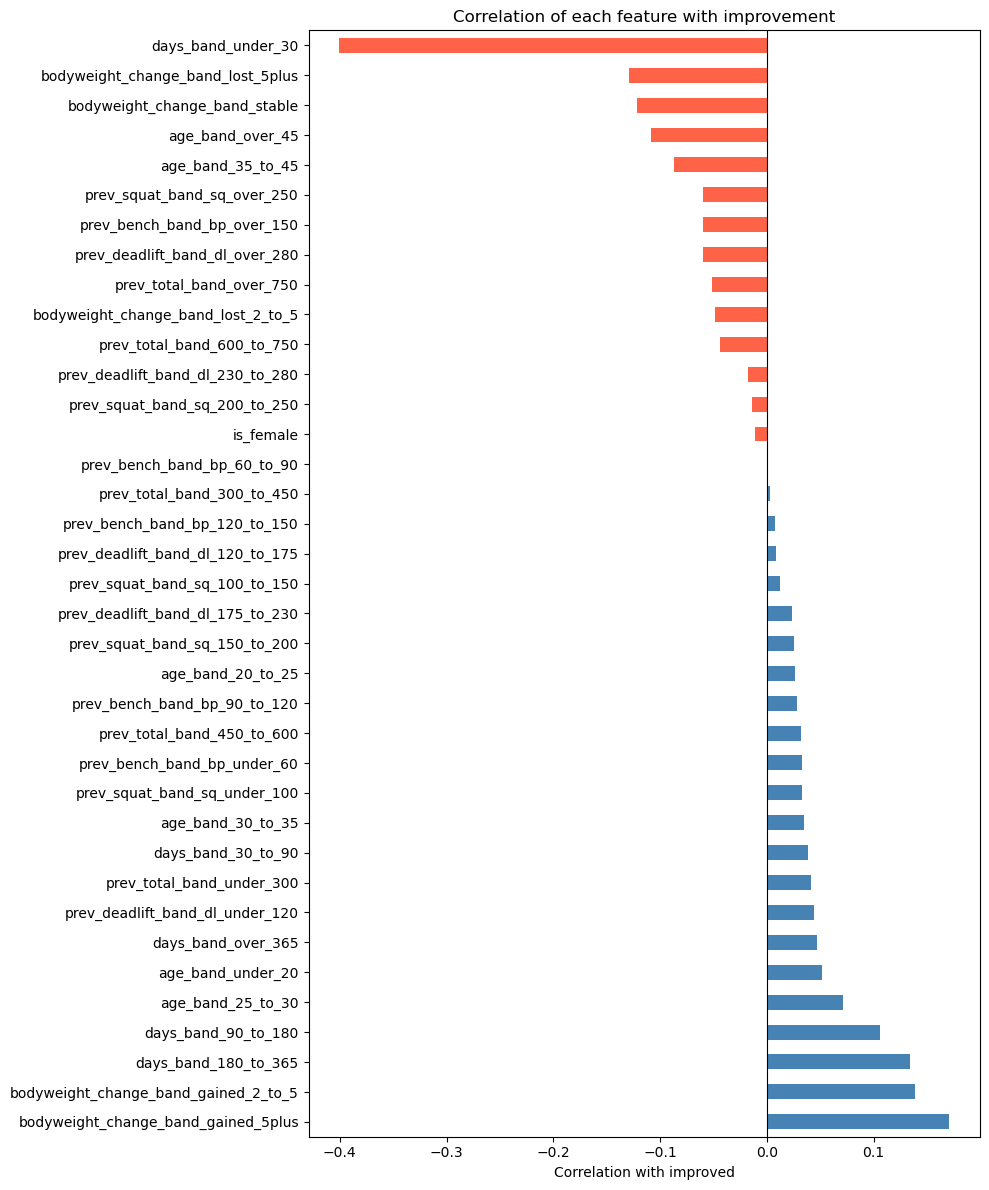

In [36]:
#Before we actualy use the data lets do a correlation analaysis to see if there are any features that are highly correleated and can leak data
# A correlation measures how strongly each feature is related to the target variable (improved).
# The value ranges from -1 to +1:
#   +1  = when this feature is True, the lifter almost always improved
#   -1  = when this feature is True, the lifter almost never improved
#    0  = no clear relationship

corr = df_clean.corr(numeric_only=True)['improved'].drop('improved').sort_values(ascending=False)

# plot as a horizontal bar chart - positive correlations in blue, negative in red
plt.figure(figsize=(10, 12))
colors = ['steelblue' if v > 0 else 'tomato' for v in corr]
corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of each feature with improvement')
plt.xlabel('Correlation with improved')
plt.tight_layout()
plt.show()



In [ ]:
# from this we can see that these is nothing that would leak data a large amount and also the observations make sense with more time there is a higher chance for PRs I will say that this data base is not perfect for our use case but
# its the best data we can find for improvement over time we will also include the users own data when training 